# Лабораторная работа: кластеризация пользователей кредитных карт

В работе используются 3 алгоритма кластеризации из `sklearn`: `KMeans`, `AgglomerativeClustering`, `GaussianMixture`.

Сравнение проводится по метрикам:
- `Silhouette` (больше — лучше),
- `Calinski-Harabasz` (больше — лучше),
- `Davies-Bouldin` (меньше — лучше).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [2]:
# 1. Загрузка данных
df = pd.read_csv("CC GENERAL.csv")
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# 2. Предобработка
# CUST_ID не является числовым признаком поведения, удаляем его
feature_names = [c for c in df.columns if c != "CUST_ID"]
X_raw = df[feature_names].copy()

# Заполняем пропуски медианой
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_raw)

# Масштабируем признаки
scaler = StandardScaler()
X = scaler.fit_transform(X_imputed)

print("Количество признаков:", X.shape[1])
print("Пропуски после обработки:", np.isnan(X).sum())

Количество признаков: 17
Пропуски после обработки: 0


In [4]:
# 3. Подбор числа кластеров для KMeans (по Silhouette)
ks = range(2, 11)
search_rows = []

for k in ks:
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X)
    search_rows.append({
        "k": k,
        "silhouette": silhouette_score(X, labels_k),
        "calinski_harabasz": calinski_harabasz_score(X, labels_k),
        "davies_bouldin": davies_bouldin_score(X, labels_k)
    })

search_df = pd.DataFrame(search_rows)
best_k = int(search_df.loc[search_df["silhouette"].idxmax(), "k"])
print("Оптимальное k по Silhouette:", best_k)
search_df

Оптимальное k по Silhouette: 3


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.210043,1706.178957,1.911979
1,3,0.250619,1605.085496,1.596848
2,4,0.197679,1598.076876,1.574837
3,5,0.193112,1482.668187,1.549204
4,6,0.202860,1419.699364,1.506422
5,7,0.215173,1361.823874,1.396876
6,8,0.221698,1331.973443,1.369689
7,9,0.226034,1317.572228,1.294268
8,10,0.223717,1281.361260,1.328261


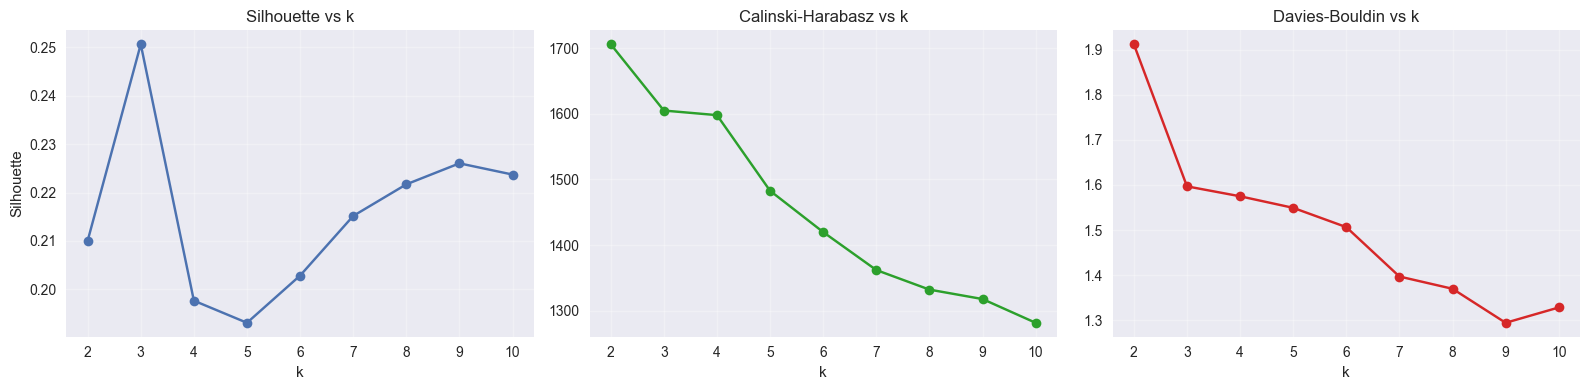

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(search_df["k"], search_df["silhouette"], marker="o")
ax[0].set_title("Silhouette vs k")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Silhouette")

ax[1].plot(search_df["k"], search_df["calinski_harabasz"], marker="o", color="tab:green")
ax[1].set_title("Calinski-Harabasz vs k")
ax[1].set_xlabel("k")

ax[2].plot(search_df["k"], search_df["davies_bouldin"], marker="o", color="tab:red")
ax[2].set_title("Davies-Bouldin vs k")
ax[2].set_xlabel("k")

for a in ax:
    a.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# 4. Обучение 3 алгоритмов с выбранным числом кластеров
models = {
    "KMeans": KMeans(n_clusters=best_k, random_state=42, n_init=20),
    "Agglomerative": AgglomerativeClustering(n_clusters=best_k, linkage="ward"),
    "GaussianMixture": GaussianMixture(n_components=best_k, covariance_type="full", random_state=42)
}

labels_dict = {}
metrics_rows = []

for name, model in models.items():
    labels = model.fit_predict(X)
    labels_dict[name] = labels

    metrics_rows.append({
        "model": name,
        "clusters": len(np.unique(labels)),
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values(by="silhouette", ascending=False).reset_index(drop=True)
metrics_df

,model,clusters,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,3,0.250619,1605.085496,1.596848
1,Agglomerative,3,0.167447,1239.325647,1.849565
2,GaussianMixture,3,0.097797,815.782030,2.996813


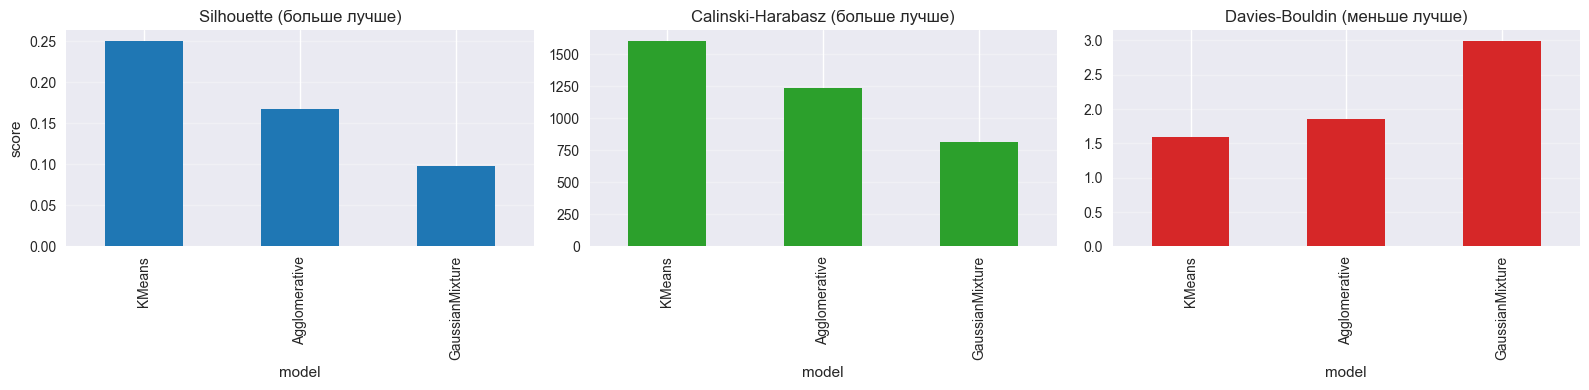

In [7]:
# Визуализация метрик
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

metrics_df.plot(kind="bar", x="model", y="silhouette", legend=False, ax=ax[0], color="tab:blue")
ax[0].set_title("Silhouette (больше лучше)")
ax[0].set_ylabel("score")

metrics_df.plot(kind="bar", x="model", y="calinski_harabasz", legend=False, ax=ax[1], color="tab:green")
ax[1].set_title("Calinski-Harabasz (больше лучше)")

metrics_df.plot(kind="bar", x="model", y="davies_bouldin", legend=False, ax=ax[2], color="tab:red")
ax[2].set_title("Davies-Bouldin (меньше лучше)")

for a in ax:
    a.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

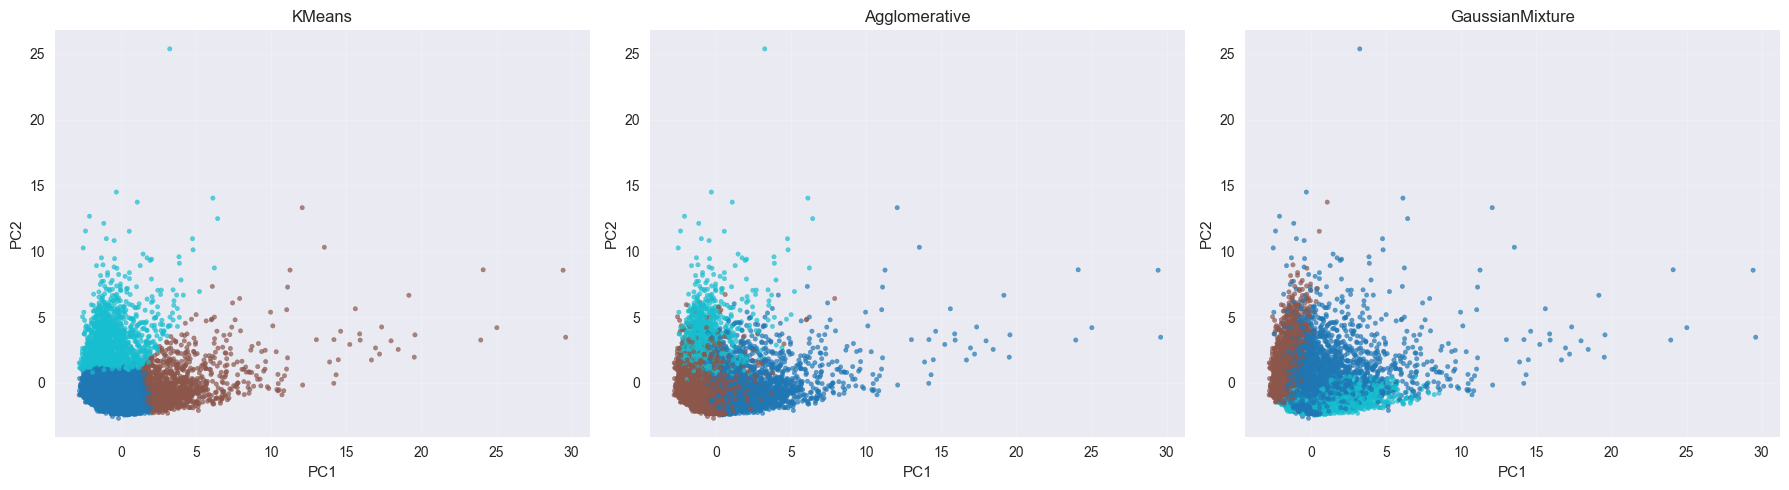

Доля объясненной дисперсии PCA(2): 0.4761145096128461


In [8]:
# 5. Визуализация кластеров в 2D через PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, labels) in zip(axes, labels_dict.items()):
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=10, cmap="tab10", alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Доля объясненной дисперсии PCA(2):", pca.explained_variance_ratio_.sum())

In [9]:
# 6. Оценка значимости признаков для лучшей модели (KMeans)
# Используем долю межкластерной дисперсии в общей дисперсии: eta^2
best_model_name = metrics_df.iloc[0]["model"]
best_labels = labels_dict[best_model_name]

X_df = pd.DataFrame(X_imputed, columns=feature_names)
overall_mean = X_df.mean()
ss_total = ((X_df - overall_mean) ** 2).sum()
ss_between = pd.Series(0.0, index=feature_names)

for cl in np.unique(best_labels):
    grp = X_df[best_labels == cl]
    diff = (grp.mean() - overall_mean) ** 2
    ss_between += len(grp) * diff

eta2 = (ss_between / ss_total).sort_values(ascending=False)

print("Лучшая модель по Silhouette:", best_model_name)
print("Топ-10 значимых признаков:")
display(eta2.head(10).to_frame("eta2"))
print("Наименее значимые признаки:")
display(eta2.tail(8).to_frame("eta2"))

Лучшая модель по Silhouette: KMeans
Топ-10 значимых признаков:


,eta2
CASH_ADVANCE_FREQUENCY,0.528489
PURCHASES_TRX,0.454002
CASH_ADVANCE,0.411848
ONEOFF_PURCHASES_FREQUENCY,0.390845
CASH_ADVANCE_TRX,0.390327
PURCHASES,0.374366
BALANCE,0.347966
ONEOFF_PURCHASES,0.262483
INSTALLMENTS_PURCHASES,0.256817
PURCHASES_FREQUENCY,0.256713


Наименее значимые признаки:


,eta2
PURCHASES_FREQUENCY,0.256713
CREDIT_LIMIT,0.250703
PAYMENTS,0.186788
PURCHASES_INSTALLMENTS_FREQUENCY,0.182603
BALANCE_FREQUENCY,0.069308
PRC_FULL_PAYMENT,0.063896
MINIMUM_PAYMENTS,0.045705
TENURE,0.016090


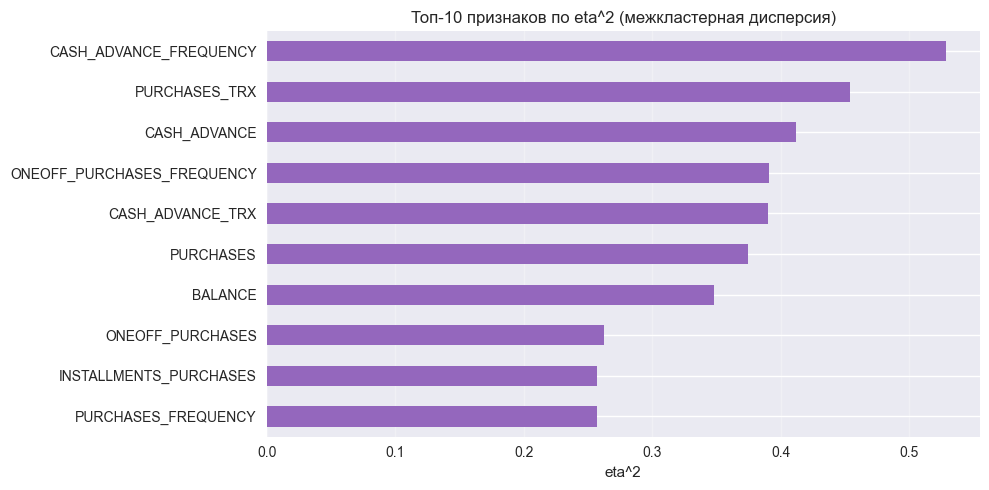

In [10]:
plt.figure(figsize=(10, 5))
eta2.head(10).sort_values().plot(kind="barh", color="tab:purple")
plt.title("Топ-10 признаков по eta^2 (межкластерная дисперсия)")
plt.xlabel("eta^2")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Выводы

1. **Какая модель сработала лучше.** По трём метрикам (`Silhouette`, `Calinski-Harabasz`, `Davies-Bouldin`) впереди оказался **KMeans**.
   Его кластеры вышли более чёткими, чем у остальных моделей.

2. **Сколько кластеров брать.** При переборе `k` от 2 до 10 лучший `Silhouette` получился при **k = 3**.
   Значит, в этом наборе данных логично делить клиентов на **3 группы**.

3. **Что сильнее всего влияет на разделение.** По `eta^2` в топе признаки, связанные с активностью по операциям: `CASH_ADVANCE_FREQUENCY`, `PURCHASES_TRX`, `CASH_ADVANCE`, `ONEOFF_PURCHASES_FREQUENCY`, `CASH_ADVANCE_TRX`, `PURCHASES`.
   Слабее всего в текущем разбиении влияют `TENURE`, `MINIMUM_PAYMENTS`, `PRC_FULL_PAYMENT`, `BALANCE_FREQUENCY`.

4. **Одинаково ли полезны все признаки.** Нет. Часть признаков почти не помогает разделять клиентов, и это видно по низким значениям `eta^2`.

5. **Как можно описать получившиеся группы.** Если коротко, это:
   - клиенты с низкой или умеренной активностью,
   - активные покупатели,
   - клиенты, которые часто используют cash advance.

   Финальную бизнес-интерпретацию лучше делать уже по средним значениям признаков внутри каждой группы.